### This notebook is used to map extracted TCR data to adata and combine corresponding TCR batch data together in one csv file for simpler downstream tcr analysis

In [2]:
import os
import re
import tarfile
import glob
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr, kruskal, entropy

import dandelion as ddl

tcr_batch_dir = "/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged"
batch_files = sorted(
    glob.glob(os.path.join(tcr_batch_dir, "*filtered_contig_annotations.csv"))
)

cd4_adata_path = "/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi_tcr.h5ad"
cd8_adata_path = "/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi_tcr.h5ad"
out_root = "/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged/tcr_final"
os.makedirs(out_root, exist_ok=True)

## Load preprocessed adata object

#### cd4

In [2]:
adata_cd4 = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")
adata_cd4.var_names_make_unique()
adata_cd4

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [3]:
# Compute neighborhood graph (if not already done)
sc.pp.neighbors(adata_cd4, use_rep="X_scVI") 

# Run Leiden clustering
sc.tl.leiden(adata_cd4, resolution=1.0, flavor="igraph")


2026-04-15 12:08:08.371949: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 12:08:08.798230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


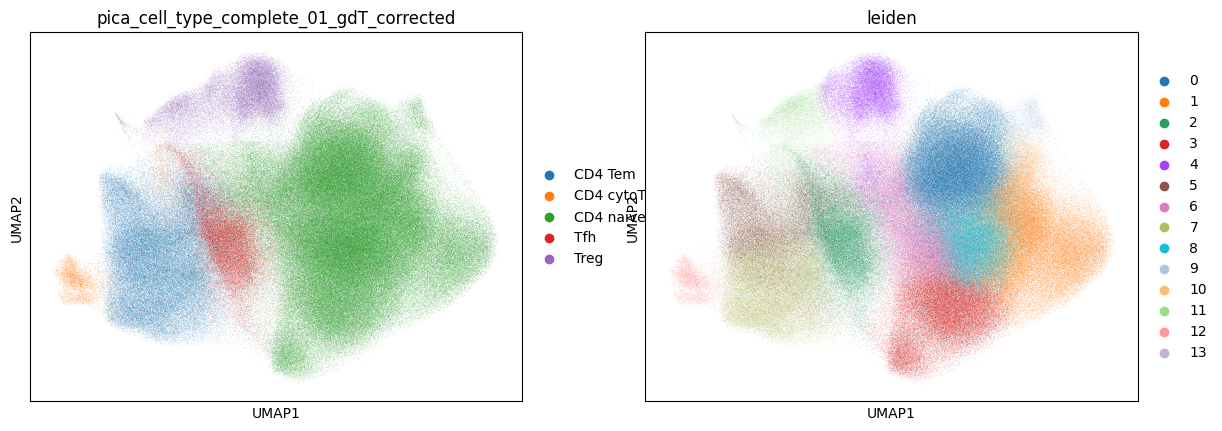

In [4]:
sc.pl.umap(adata_cd4, color=["pica_cell_type_complete_01_gdT_corrected", "leiden"])

In [5]:
adata_cd4

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [6]:
adata_cd4.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi_tcr.h5ad", compression="gzip")

In [7]:
adata_cd4.obs["sequencing_batch"].head()

20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAAAGCGT    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACAATAG    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACTTACG    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAAAGGGGA    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCACAGTGCC    20240918_WGS_20240924_sc_PICA0008-PICA0032
Name: sequencing_batch, dtype: category
Categories (7, object): ['20240530_WGS_20240530_sc_PICA0001-PICA0007', '20240918_WGS_20240924_sc_PICA0008-PICA0032', '20241106_WGS_20241106_sc_PICA0033-PICA0069', '20250114_WGS_20241218_sc_PICA0071-PICA0097', '20250324_WGS_20250324_sc_PICA0098-PICA0118', '20250612_WGS_20250612_sc_PICA0119-PICA0146', '20250814_WGS_20250814_sc_PICA0147-PICA0173']

In [8]:
cd4_barcodes = set(adata_cd4.obs_names.astype(str))

print(f"CD4 RNA barcodes: {len(cd4_barcodes):,}")
print("Example CD4 barcode:", next(iter(cd4_barcodes)))

CD4 RNA barcodes: 596,486
Example CD4 barcode: 20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_3_AAACCTGTCATCGGAC


#### cd8

In [9]:
adata_cd8 = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad")
adata_cd8.var_names_make_unique()
adata_cd8

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [10]:
# Compute neighborhood graph (if not already done)
sc.pp.neighbors(adata_cd8, use_rep="X_scVI") 

# Run Leiden clustering
sc.tl.leiden(adata_cd8, resolution=1.0, flavor="igraph")


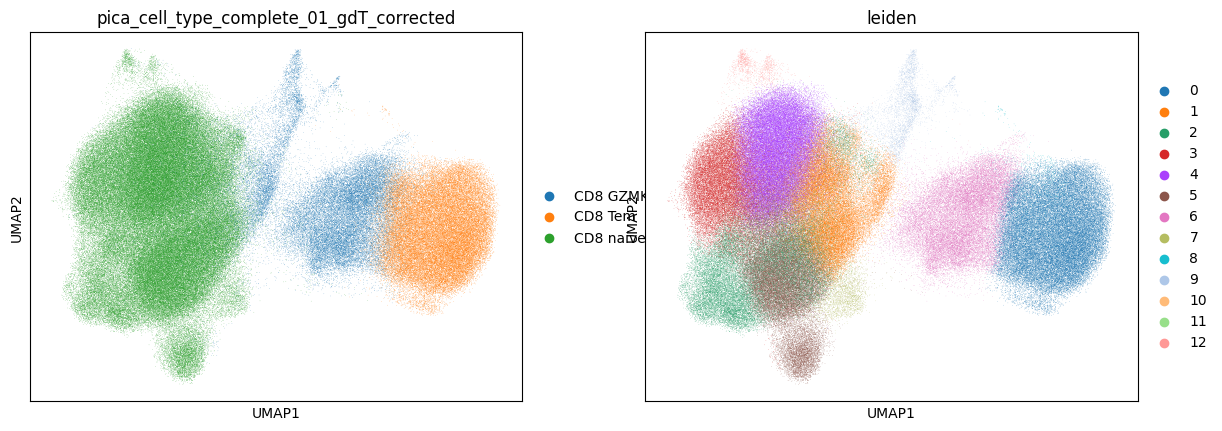

In [11]:
sc.pl.umap(adata_cd8, color=["pica_cell_type_complete_01_gdT_corrected", "leiden"])

In [12]:
adata_cd8

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [13]:
adata_cd8.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi_tcr.h5ad", compression="gzip")

In [14]:
adata_cd8.obs["sequencing_batch"].head()

20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAGGCTTCA    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCATGGCGT    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCCTCGCAC    20240918_WGS_20240924_sc_PICA0008-PICA0032
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCGGCATTA    20240918_WGS_20240924_sc_PICA0008-PICA0032
Name: sequencing_batch, dtype: category
Categories (7, object): ['20240530_WGS_20240530_sc_PICA0001-PICA0007', '20240918_WGS_20240924_sc_PICA0008-PICA0032', '20241106_WGS_20241106_sc_PICA0033-PICA0069', '20250114_WGS_20241218_sc_PICA0071-PICA0097', '20250324_WGS_20250324_sc_PICA0098-PICA0118', '20250612_WGS_20250612_sc_PICA0119-PICA0146', '20250814_WGS_20250814_sc_PICA0147-PICA0173']

In [15]:
cd8_barcodes = set(adata_cd8.obs_names.astype(str))

print(f"CD4 RNA barcodes: {len(cd8_barcodes):,}")
print("Example CD4 barcode:", next(iter(cd8_barcodes)))

CD4 RNA barcodes: 265,568
Example CD4 barcode: 20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_6_GTTGATCCACCGTCAA


## Checking TCR data against adata

In [20]:
def filter_and_save(subset_name: str, adata_path: str):
    print(f"\n{'='*20} {subset_name} {'='*20}")

    out_dir = os.path.join(out_root, subset_name.lower())
    os.makedirs(out_dir, exist_ok=True)

    out_file = os.path.join(out_dir, "filtered_contig_annotations.csv")
    summary_file = os.path.join(out_dir, "batch_summary.csv")

    if os.path.exists(out_file):
        os.remove(out_file)

    print(f"Loading {subset_name} adata...")
    adata = sc.read_h5ad(adata_path, backed="r")
    rna_barcodes = set(adata.obs_names.astype(str))

    print(f"{subset_name} RNA barcodes: {len(rna_barcodes):,}")
    print(f"Example {subset_name} barcode:", next(iter(rna_barcodes)))

    all_kept = []
    summary = []

    for f in batch_files:
        batch_name = os.path.basename(f).replace("_filtered_contig_annotations.csv", "")
        print(f"\n=== Processing {subset_name} | {batch_name} ===")

        df = pd.read_csv(f)

        if "barcode" not in df.columns:
            raise ValueError(f"'barcode' column not found in {f}")

        # harmless if already stripped
        df["barcode"] = (
            df["barcode"]
            .astype(str)
            .str.replace("_PMID_97-101", "", regex=False)   
            .str.replace("-1$", "", regex=True)              
        )

        kept_df = df[df["barcode"].isin(rna_barcodes)].copy()

        print(f"  Rows in file: {len(df):,}")
        print(f"  Rows kept:    {len(kept_df):,}")

        summary.append({
            "subset": subset_name,
            "batch": batch_name,
            "rows_in_file": len(df),
            "rows_kept": len(kept_df),
            "unique_barcodes_kept": kept_df["barcode"].nunique() if len(kept_df) > 0 else 0
        })

        if len(kept_df) > 0:
            all_kept.append(kept_df)

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(summary_file, index=False)

    print(f"\n{subset_name} batch summary:")
    print(summary_df)

    if all_kept:
        merged_present = pd.concat(all_kept, ignore_index=True)
        merged_present = merged_present.drop_duplicates()

        merged_present.to_csv(out_file, index=False)

        print(f"\n{subset_name} done.")
        print(f"Output written to: {out_file}")
        print(f"Summary written to: {summary_file}")
        print(f"Total kept rows: {len(merged_present):,}")
        print(f"Unique barcodes: {merged_present['barcode'].nunique():,}")
        print(f"Duplicate barcodes: {merged_present['barcode'].duplicated().sum():,}")
    else:
        print(f"\nNo matching TCR rows found for {subset_name}.")

In [21]:
# Save combine TCR data
filter_and_save("CD4", cd4_adata_path)
filter_and_save("CD8", cd8_adata_path)


==================== CD4 ====================
Loading CD4 adata...
CD4 RNA barcodes: 596,486
Example CD4 barcode: 20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_6_ATCAAGGCAGCTAGAA

=== Processing CD4 | 20240530_WGS_20240530_sc_PICA0001-PICA0007_PMID_97-101 ===
  Rows in file: 13,068
  Rows kept:    8,329

=== Processing CD4 | 20240918_WGS_20240924_sc_PICA0008-PICA0032 ===
  Rows in file: 507,802
  Rows kept:    211,719

=== Processing CD4 | 20241106_WGS_20241106_sc_PICA0033-PICA0069 ===
  Rows in file: 436,313
  Rows kept:    195,338

=== Processing CD4 | 20250114_WGS_20241218_sc_PICA0071-PICA0097 ===
  Rows in file: 506,725
  Rows kept:    246,517

=== Processing CD4 | 20250324_WGS_20250324_sc_PICA0098-PICA0118 ===
  Rows in file: 303,550
  Rows kept:    133,420

=== Processing CD4 | 20250612_WGS_20250612_sc_PICA0119-PICA0146 ===
  Rows in file: 490,578
  Rows kept:    194,984

=== Processing CD4 | 20250814_WGS_20250814_sc_PICA0147-PICA0173 ===
  Rows in file: 285,508
  Rows kept:  

In [22]:

tcr_cd4 = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged/tcr_final/cd4/filtered_contig_annotations.csv")
adata_cd4 = sc.read_h5ad(cd4_adata_path, backed="r")

print("TCR example:")
print(tcr_cd4["barcode"].head())

print("\nRNA example:")
print(adata_cd4.obs_names[:5])

TCR example:
0    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
1    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
2    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
3    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
4    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
Name: barcode, dtype: object

RNA example:
Index(['20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAAAGCGT',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACAATAG',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACTTACG',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAAAGGGGA',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCACAGTGCC'],
      dtype='object')


In [23]:
tcr_cd4_barcodes = set(tcr_cd4["barcode"].unique())
rna_cd4_barcodes = set(adata_cd4.obs_names.astype(str))

overlap = len(tcr_cd4_barcodes & rna_cd4_barcodes)

print("Unique TCR barcodes:", len(tcr_cd4_barcodes))
print("RNA barcodes:", len(rna_cd4_barcodes))
print("Overlap:", overlap)
print("TCR -> RNA match %:", overlap / len(tcr_cd4_barcodes)*100)
print("RNA -> TCR coverage %:", overlap / len(rna_cd4_barcodes)*100)

Unique TCR barcodes: 571042
RNA barcodes: 596486
Overlap: 571042
TCR -> RNA match %: 100.0
RNA -> TCR coverage %: 95.73435084813391


In [24]:
contigs_per_cell = tcr_cd4["barcode"].value_counts()
print(contigs_per_cell.describe())

count    571042.000000
mean          1.960856
std           0.544467
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: count, dtype: float64


In [25]:
print("Duplicated full rows:", tcr_cd4.duplicated().sum())

Duplicated full rows: 0


In [35]:

tcr_cd8 = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA_Batch001-Batch007_tcr_merged/tcr_final/cd8/filtered_contig_annotations.csv")
adata_cd8 = sc.read_h5ad(cd8_adata_path, backed="r")

print("TCR example:")
print(tcr_cd8["barcode"].head())

print("\nRNA example:")
print(adata_cd8.obs_names[:5])

TCR example:
0    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
1    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
2    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
3    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
4    20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...
Name: barcode, dtype: object

RNA example:
Index(['20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAGGCTTCA',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCATGGCGT',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCCTCGCAC',
       '20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCGGCATTA'],
      dtype='object')


In [ ]:
tcr_cd8_barcodes = set(tcr_cd8["barcode"].unique())
rna_cd8_barcodes = set(adata_cd8.obs_names.astype(str))

overlap = len(tcr_cd8_barcodes & rna_cd8_barcodes)

print("Unique TCR barcodes:", len(tcr_cd8_barcodes))
print("RNA barcodes:", len(rna_cd8_barcodes))
print("Overlap:", overlap)
print("TCR -> RNA match %:", overlap / len(tcr_cd8_barcodes)*100)
print("RNA -> TCR coverage %:", overlap / len(rna_cd8_barcodes)*100)

Unique TCR barcodes: 571042
RNA barcodes: 596486
Overlap: 571042
TCR -> RNA match %: 100.0
RNA -> TCR coverage %: 95.73435084813391


In [ ]:
contigs_per_cell = tcr_cd8["barcode"].value_counts()
print(contigs_per_cell.describe())

count    571042.000000
mean          1.960856
std           0.544467
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: count, dtype: float64


In [ ]:
print("Duplicated full rows:", tcr_cd8.duplicated().sum())

Duplicated full rows: 0
